# Top-NMF: Example 2
Graph topological NMF with built-in utilities and fixed node layout.

## Paper Hyperparameters
The following hyperparameters were used in the paper:
- `{n_components: 3, alpha: 1.0, lambda_top: 0.01}`
- `{n_components: 5, alpha: 0.1, lambda_top: 0.05}`
- `{n_components: 5, alpha: 1.0, lambda_top: 0.05}`
- `{n_components: 5, alpha: 5.0, lambda_top: 0.01}`

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
import networkx as nx
from itertools import combinations

from TopNMF import *

2026-01-18 13:20:53.104668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768710053.116195 1634521 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768710053.119697 1634521 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-18 13:20:53.131423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def generate_clique_dataset(
    cliques=((1, 2, 3, 4, 5), (5, 6, 7), (6, 7, 8, 9)),
    weights=((2, 1, 2), (1, 2, 1), (1, 1, 2)),
):
    all_nodes = sorted({i for clique in cliques for i in clique})
    edge_list = [tuple(sorted(e)) for e in combinations(all_nodes, 2)]
    edge_index = {e: i for i, e in enumerate(edge_list)}
    X = []

    for alpha in weights:
        row = np.zeros(len(edge_list))
        for coeff, clique in zip(alpha, cliques):
            for u, v in combinations(clique, 2):
                row[edge_index[tuple(sorted((u, v)))]] += coeff
        X.append(row)

    return np.stack(X), edge_list

X, all_edges = generate_clique_dataset()
print(f"X shape: {X.shape}, edges: {len(all_edges)}")


X shape: (3, 36), edges: 36


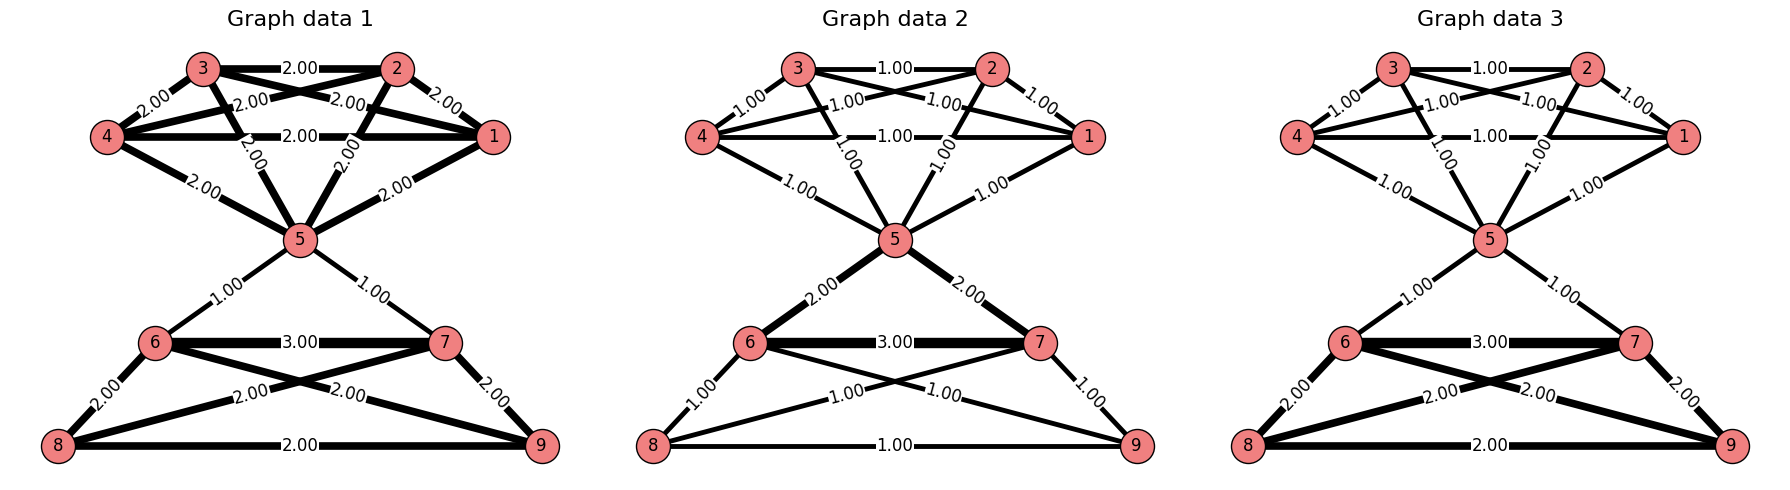

In [3]:
# Fixed node coordinates for consistent layouts
fixed_pos = {
    5: (0, 0),
    4: (-2, 1.5), 3: (-1, 2.5), 2: (1, 2.5), 1: (2, 1.5),
    6: (-1.5, -1.5), 7: (1.5, -1.5), 8: (-2.5, -3.0), 9: (2.5, -3.0),
}
all_x = [pos[0] for pos in fixed_pos.values()]
all_y = [pos[1] for pos in fixed_pos.values()]
global_xlim = (min(all_x) - 0.5, max(all_x) + 0.5)
global_ylim = (min(all_y) - 0.5, max(all_y) + 0.5)

def norm_edge(e):
    return tuple(sorted(e))

def plot_graphs_fixed(edge_weights_matrix, edge_list, title):
    threshold = 0.1
    n_components = edge_weights_matrix.shape[0]
    cols = 3
    rows = int(np.ceil(n_components / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.atleast_2d(axes)

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        ax.clear()
        if i >= n_components:
            ax.axis('off')
            continue

        weights = edge_weights_matrix[i]
        edge_weights = {}
        for idx, w in enumerate(weights):
            if w > threshold:
                e = norm_edge(edge_list[idx])
                edge_weights[e] = edge_weights.get(e, 0.0) + float(w)

        G = nx.Graph()
        G.add_edges_from(edge_weights.keys())

        if G.number_of_nodes() > 0:
            nx.draw_networkx_nodes(G, fixed_pos, node_color='lightcoral', node_size=600, edgecolors='black', ax=ax)
            nx.draw_networkx_labels(G, fixed_pos, font_size=12, font_color='black', ax=ax)

            edge_widths = [1.5 + edge_weights[norm_edge((u, v))] * 2 for u, v in G.edges()]
            nx.draw_networkx_edges(G, fixed_pos, edge_color='black', width=edge_widths, ax=ax)

            edge_labels_dict = {(u, v): f"{edge_weights[norm_edge((u, v))]:.2f}" for u, v in G.edges()}
            nx.draw_networkx_edge_labels(
                G, fixed_pos,
                edge_labels=edge_labels_dict,
                font_color='black',
                font_size=12,
                label_pos=0.5,
                bbox=dict(facecolor='white', edgecolor='none', alpha=1.0, pad=0.3),
                ax=ax,
            )
        else:
            ax.text(0, 0, 'No Active Components', ha='center', va='center', fontsize=12)

        ax.set_title(f"{title} {i + 1}", fontsize=16)
        ax.set_xlim(global_xlim)
        ax.set_ylim(global_ylim)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_graphs_fixed(X, all_edges, title='Graph data')


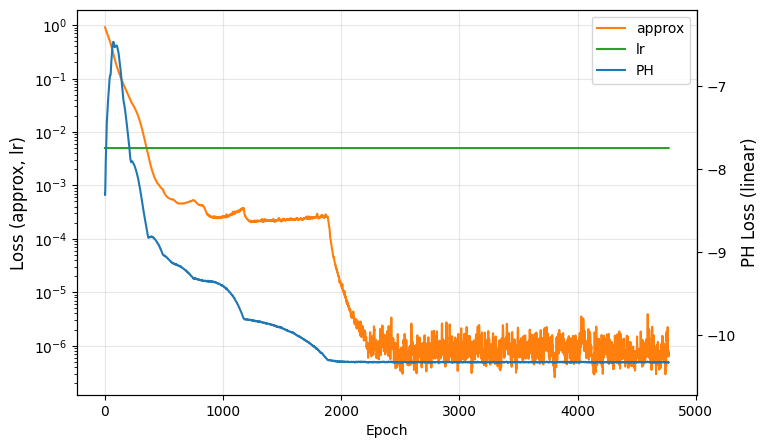

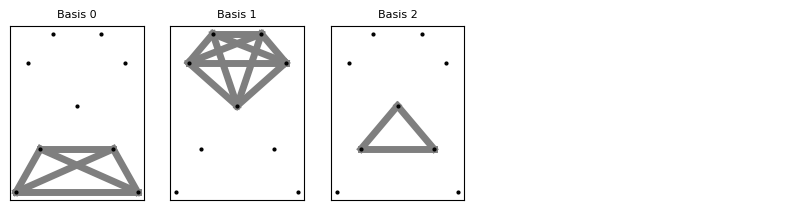

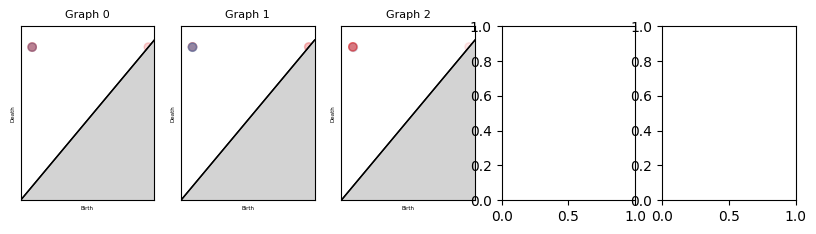

  0%|          | 0/5000 [00:00<?, ?it/s]

/home/keunsu/.local/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:112: UserWarning: usetex mode requires dvipng.
  warnings.warn("usetex mode requires dvipng.")


In [4]:
device = 'cpu'
n_components = 3

ph_complex = GraphFiltrationPH(max_dim=1, superlevel=True)

## specify target PH (or set to None for sparsity)
target_diagrams = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]

model = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=43,
    complex=ph_complex,
    use_embedding=False,
    ph_loss_fn=clique_deviation_loss,    
    ph_loss_params={"alpha": 1.0, 'remove_longest': {0: False, 1: False}}      
)

model.fit(
    X,
    n_iterations=5000,
    lr=0.005,
    lambda_top=0.01,
    PH_dims=[0, 1],
    complex_inputs={'all_edges': all_edges, 'node_pos': fixed_pos},
    show_plots=['loss', 'PH', 'basis'],  
    disp_interval=10,
    verbose=True, 
    target_diagrams=target_diagrams,
    normalize_V_max = True,
    superlevel = True,
    init_method = 'random',
    plot_grid = (1,5)
)

plt.close('all')

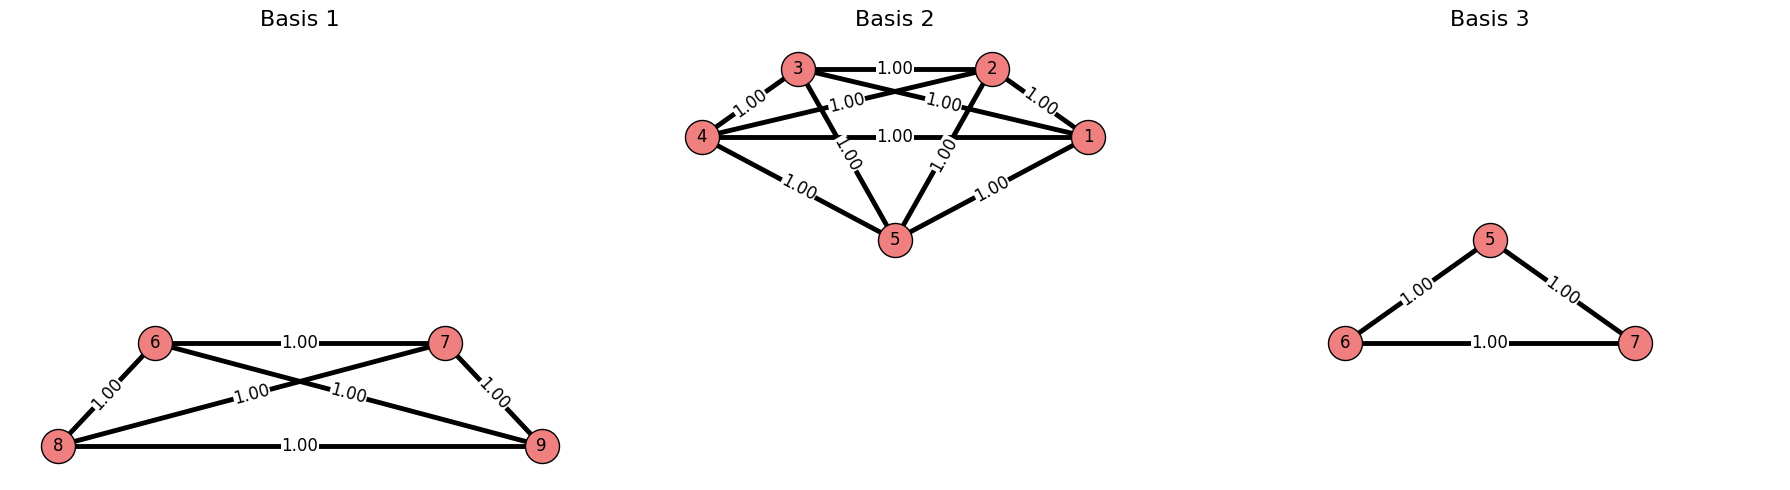

In [5]:
plot_graphs_fixed(model.V.detach().cpu().numpy(), all_edges, title='Basis')